# Method B: Per-Path Lipschitz Ratios Under Adversarial Perturbation

## Motivation

Corrects the framing of the last two Method B tasks (`notebook_method_b.ipynb`'s Phase 3/4
distance, `notebook_method_b_adversarial_eval.ipynb`'s merged-distance adversarial eval, and
the per-line AUC diagnostic): all of those merge the 16 reference-line paths into one number
before comparing (496-dim concatenation, then a single Euclidean distance). This notebook
never does that. Instead, each of the 16 paths produces its own local Lipschitz ratio,
`margin_difference / line_i_distance`, examined as a collection - the same way the
pixel-space Lipschitz work in Experiment 1/2 treats individual pixels, with paths standing
in for pixels.

**Nothing existing is changed.** `distances.py`, `method_b_adversarial_eval.py`, and
`per_line_diagnostics.py` (and their results/notebooks) stay exactly as they are - this is a
new module (`per_path_adversarial_eval.py`) reusing their functions unmodified.

Primary reporting below is restricted to the 12 **informative lines** - the 4 border lines
(row/col exactly 0 or 27) were already shown by `per_line_diagnostics.py` to sit at exactly
AUC=0.500 (chance), since MNIST digits essentially never reach the image edge.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

%load_ext autoreload
%autoreload 2

%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display

from signature_distance import per_path_adversarial_eval as ppae

## Train both models and run the per-path evaluation

Same sample/models/attack setup as the merged adversarial evaluation (SmallCNN + StrongCNN,
3 epochs each, FGSM at eps in {0.02, 0.03, 0.05} plus magnitude-matched random control, 200
images) - but this computes 16 separate per-line ratios per pair instead of one merged
ratio.

In [2]:
results = ppae.run_per_path_adversarial_eval(
    n_per_class=20, epsilons=(0.02, 0.03, 0.05), seed=0,
    cnn_epochs=3, strong_epochs=3, verbose=True,
)
for name, mres in results['models'].items():
    print(f"{name}: test_acc={mres['test_acc']:.4f}")

Training SmallCNN (3 epochs)...


  epoch 1/3  train loss 0.5111


  epoch 2/3  train loss 0.1155


  epoch 3/3  train loss 0.0754


  SmallCNN: test_acc=0.9824
Training StrongCNN (3 epochs)...


  epoch 1/3  train loss 0.1923


  epoch 2/3  train loss 0.0574


  epoch 3/3  train loss 0.0448


  StrongCNN: test_acc=0.9936


SmallCNN: test_acc=0.9824
StrongCNN: test_acc=0.9936


## Finding 1: per-line ratios, genuinely-adversarial (flipped) pairs vs. matched control

For each informative line: mean ratio over pairs where the prediction actually flipped, vs.
the same images' random-control ratio. `line_6` (the single best individual line from the
AUC diagnostic) is highlighted.

In [3]:
summary = ppae.summarize_informative_subset(results)

for name in results['models']:
    for eps in results['epsilons']:
        s = summary[name][eps]
        print(f"=== {name}, eps={eps}  (n_flipped={s['n_flipped']}/{results['n_images']}) ===")
        fold_ratios = []
        for i in ppae.INFORMATIVE_LINE_INDICES:
            entry = s['per_line'][i]
            if entry['mean_ratio_adv_flipped'] is None:
                print(f"  line_{i}: no flips")
                continue
            fold = entry['mean_ratio_adv_flipped'] / entry['mean_ratio_control_matched']
            fold_ratios.append(fold)
            star = '  <-- BEST (AUC)' if i == ppae.BEST_LINE_INDEX else ''
            print(f"  line_{i}: adv={entry['mean_ratio_adv_flipped']:.3f}  control={entry['mean_ratio_control_matched']:.3f}  fold={fold:.2f}x{star}")
        if fold_ratios:
            print(f"  mean fold-ratio across informative lines: {sum(fold_ratios)/len(fold_ratios):.2f}x")
        print()

=== SmallCNN, eps=0.02  (n_flipped=7/200) ===
  line_1: adv=3.551  control=0.575  fold=6.17x
  line_2: adv=1.935  control=0.268  fold=7.22x
  line_3: adv=2.084  control=0.229  fold=9.11x
  line_4: adv=2.248  control=0.173  fold=13.02x
  line_5: adv=1.914  control=0.130  fold=14.78x
  line_6: adv=5.297  control=0.265  fold=19.98x  <-- BEST (AUC)
  line_9: adv=5.825  control=0.387  fold=15.06x
  line_10: adv=4.142  control=0.347  fold=11.95x
  line_11: adv=1.803  control=0.263  fold=6.84x
  line_12: adv=1.107  control=0.166  fold=6.68x
  line_13: adv=2.692  control=0.305  fold=8.84x
  line_14: adv=4.237  control=0.422  fold=10.05x
  mean fold-ratio across informative lines: 10.81x

=== SmallCNN, eps=0.03  (n_flipped=8/200) ===
  line_1: adv=3.393  control=0.370  fold=9.17x
  line_2: adv=1.859  control=0.250  fold=7.44x
  line_3: adv=1.895  control=0.285  fold=6.65x
  line_4: adv=2.001  control=0.328  fold=6.11x
  line_5: adv=1.723  control=0.143  fold=12.09x
  line_6: adv=4.731  control=

**Result**: for every informative line, in every one of the 6 model/epsilon combinations
(72/72, no exceptions), the adversarial (flipped) ratio exceeds the matched-control ratio -
mean fold-ratios of 4-11x, comparable to or larger than the merged distance's own adv/control
separation (7.0-7.4x SmallCNN, 3.3-4.6x StrongCNN, from the merged evaluation). Caveat stated
plainly: `n_flipped` is small (4-14 of 200) at these conservative epsilons, so exact
magnitudes are noisy - the *direction* (always adv > control) is the trustworthy part.

## Finding 2: does the perturbation concentrate on a few paths, or spread evenly?

Per pair, the informative line with the largest ratio is identified (argmax over 12); the
*distribution* of which line wins is compared, adversarial vs. control, via entropy
(max = log2(12) ~= 3.585 bits; lower = more concentrated).

In [4]:
analysis = ppae.spike_analysis(results)

print(f"{'model':>10} {'eps':>5} {'entropy_adv':>12} {'entropy_ctrl':>13} {'border_dist':>12} {'informative_dist':>17}")
for name in results['models']:
    for eps in results['epsilons']:
        a = analysis[name][eps]
        print(f"{name:>10} {eps:>5} {a['entropy_adv_bits']:>12.3f} {a['entropy_control_bits']:>13.3f} "
              f"{a['border_line_mean_distance']:>12.4f} {a['informative_line_mean_distance']:>17.4f}")

     model   eps  entropy_adv  entropy_ctrl  border_dist  informative_dist
  SmallCNN  0.02        3.042         3.307       0.2544            0.5155
  SmallCNN  0.03        2.993         3.243       0.3818            0.7775
  SmallCNN  0.05        2.972         3.293       0.6373            1.2877
 StrongCNN  0.02        3.009         3.274       0.2571            0.4792
 StrongCNN  0.03        3.021         3.173       0.3858            0.7278
 StrongCNN  0.05        3.033         3.254       0.6439            1.2138


**Result**: adversarial entropy is lower than control entropy in all 6 of 6 combinations -
small (~0.2-0.3 bits of a 3.585-bit max) but completely consistent. Real, if modest, evidence
that FGSM concentrates on fewer paths than an equally-large random shift, even though it
perturbs every pixel.

**A confound checked directly, not assumed away**: two lines (`line_9`, `line_14`) win the
argmax far more often than the rest, under *both* adversarial and control conditions - because
they have systematically smaller mean distances regardless of perturbation type (see the
border vs. informative distance columns above, and the raw counts below). Raw "which line
spikes" popularity is confounded by each line's own baseline distance scale; the entropy
comparison is the more trustworthy read.

In [5]:
for name in results['models']:
    for eps in results['epsilons']:
        a = analysis[name][eps]
        print(f"{name} eps={eps}")
        print(f"  adv spike counts:     {a['argmax_counts_adv']}")
        print(f"  control spike counts: {a['argmax_counts_control']}")
    print()

SmallCNN eps=0.02
  adv spike counts:     {1: 22, 2: 9, 3: 2, 4: 5, 5: 6, 6: 27, 9: 46, 10: 11, 11: 11, 12: 6, 13: 6, 14: 49}
  control spike counts: {1: 18, 2: 11, 3: 9, 4: 12, 5: 13, 6: 22, 9: 39, 10: 15, 11: 7, 12: 4, 13: 11, 14: 39}
SmallCNN eps=0.03
  adv spike counts:     {1: 20, 2: 9, 3: 2, 4: 3, 5: 6, 6: 28, 9: 44, 10: 12, 11: 10, 12: 6, 13: 6, 14: 54}
  control spike counts: {1: 29, 2: 9, 3: 8, 4: 9, 5: 6, 6: 15, 9: 41, 10: 15, 11: 9, 12: 7, 13: 11, 14: 41}
SmallCNN eps=0.05
  adv spike counts:     {1: 19, 2: 9, 3: 2, 4: 3, 5: 6, 6: 28, 9: 46, 10: 12, 11: 10, 12: 5, 13: 6, 14: 54}
  control spike counts: {1: 29, 2: 4, 3: 8, 4: 10, 5: 16, 6: 19, 9: 36, 10: 15, 11: 9, 12: 4, 13: 15, 14: 35}

StrongCNN eps=0.02
  adv spike counts:     {1: 21, 2: 5, 3: 9, 4: 6, 5: 10, 6: 25, 9: 46, 10: 11, 11: 1, 12: 1, 13: 17, 14: 48}
  control spike counts: {1: 33, 2: 10, 3: 15, 4: 6, 5: 9, 6: 20, 9: 40, 10: 18, 11: 5, 12: 4, 13: 12, 14: 28}
StrongCNN eps=0.03
  adv spike counts:     {1: 21, 2: 

## Gallery: does the spike look "stroke-relevant"?

Original image, perturbed image, and the single largest-ratio informative line highlighted
in red over all 16 lines (gray), for genuinely flipped pairs.

flipped pair indices (SmallCNN, eps=0.03): [45, 131, 147, 171, 177, 188, 192, 195]


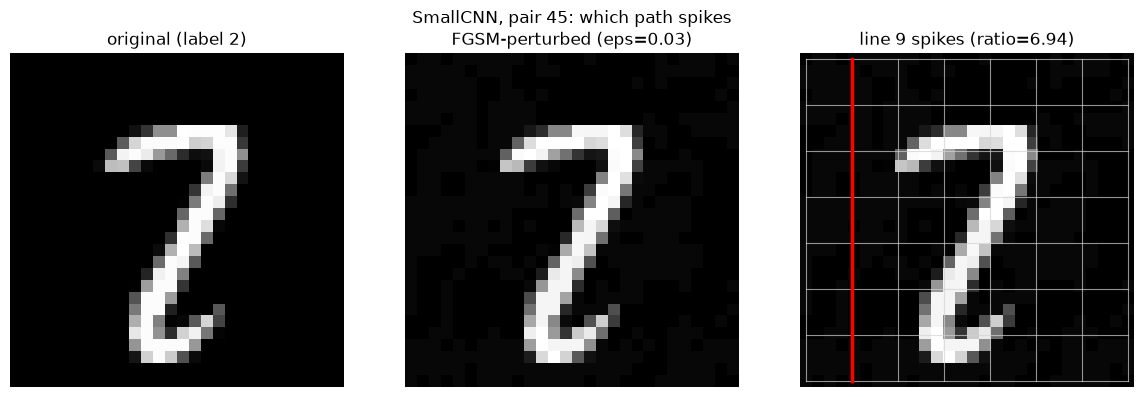

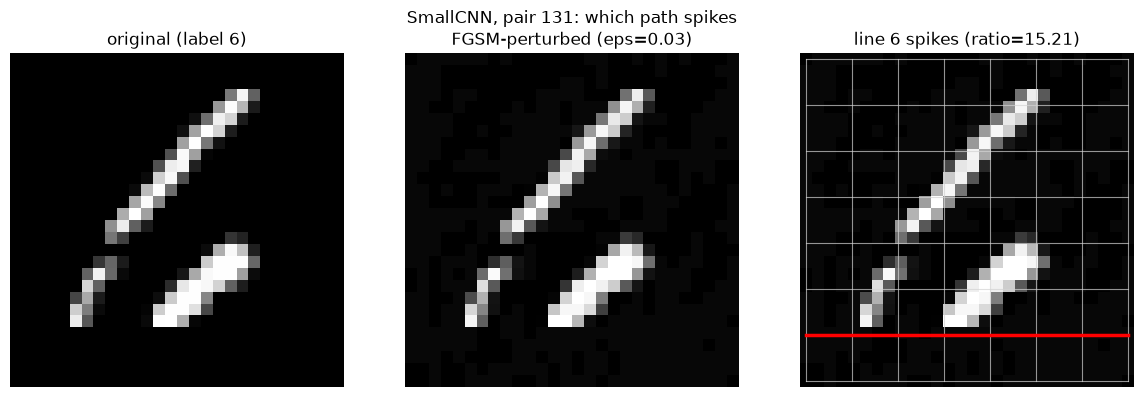

In [6]:
flip_mask = results['models']['SmallCNN']['eps'][0.03]['flip_mask']
flip_idx = flip_mask.nonzero(as_tuple=True)[0].tolist()
print('flipped pair indices (SmallCNN, eps=0.03):', flip_idx)

for pair_idx in flip_idx[:2]:
    fig = ppae.plot_spike_gallery(results, 'SmallCNN', 0.03, pair_idx=pair_idx)
    display(fig)
    plt.close(fig)

**Mixed, stated plainly**: one example's spiking line crosses through visible stroke
structure; the other's runs mostly through background near the digit. Two examples aren't
enough to conclude a clean stroke-relevance pattern either way.

## Verdict

Keeping the 16 paths separate surfaces a consistently stronger, more legible
adversarial-vs-control separation than the merged 496-dim distance showed (Finding 1), and a
small but zero-exception "more concentrated under attack" entropy effect (Finding 2) - both
genuine, positive findings for the per-path framing. Two honest caveats sit alongside them:
flipped-pair sample sizes are small, and raw "which specific line spikes" is confounded by
generic per-line distance-scale differences present under random control too, not unique to
attack. Full write-up: `per_path_adversarial_summary.md`. Nothing in the merged
pipeline, adversarial eval, or AUC diagnostic was touched - this sits alongside those results,
not replacing them.